In [2]:
!pip install pytrends

In [1]:
import pandas as pd
from pytrends.request import TrendReq

# 사용자 입력 받기 (쉼표로 구분된 키워드)
raw_input = input("검색할 키워드를 쉼표(,)로 구분해서 입력하세요 (예: python, machine learning): ")

# 입력값을 리스트로 변환하고 공백 제거
keywords = [kw.strip() for kw in raw_input.split(',') if kw.strip()]

# pytrends 객체 생성
pytrends = TrendReq(hl='en-US', tz=360)

# pytrends 요청
pytrends.build_payload(keywords, cat=0, timeframe='today 12-m', geo='', gprop='')

# 검색 트렌드 데이터 가져오기
df = pytrends.interest_over_time()

# 데이터 확인 및 정리
print(df.head())

# 시계열 예측용 준비
df = df.reset_index()
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)


검색할 키워드를 쉼표(,)로 구분해서 입력하세요 (예: python, machine learning): youtube, instagram, tiktok
            youtube  instagram  tiktok  isPartial
date                                             
2024-06-16       82         34      15      False
2024-06-23       80         33      15      False
2024-06-30       82         35      15      False
2024-07-07       81         33      15      False
2024-07-14       86         34      15      False


/usr/local/lib/python3.11/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


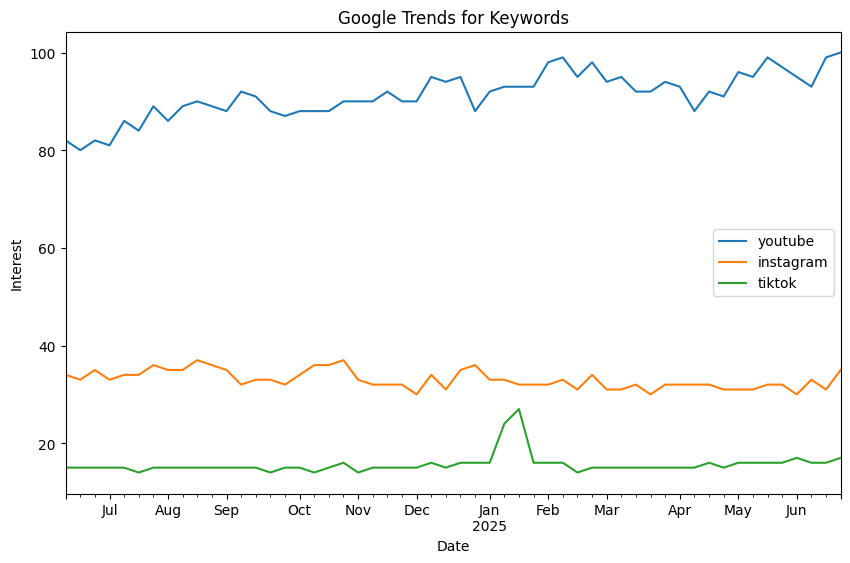

In [2]:
import matplotlib.pyplot as plt

# pytrends에서 가져온 데이터 시각화
df.plot(figsize=(10, 6))
plt.title('Google Trends for Keywords')
plt.xlabel('Date')
plt.ylabel('Interest')
plt.show()

In [5]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

# 예측할 키워드들
keywords = ['youtube', 'instagram', 'tiktok']

# 예측 결과 저장용 딕셔너리
forecast_results = {}

# 각 키워드에 대해 ARIMA 모델 학습 및 예측
for kw in keywords:
    print(f"🔎 '{kw}'에 대해 ARIMA 모델 학습 중...")

    model = ARIMA(df[kw], order=(5, 1, 0))  # 필요한 경우 order 튜닝 가능
    model_fit = model.fit()

    forecast = model_fit.forecast(steps=30)
    forecast_results[kw] = forecast

    print(forecast.head())  # 일부만 출력

# 모든 키워드 예측 결과를 하나의 DataFrame으로 정리
forecast_df = pd.DataFrame(forecast_results)
print("\n📈 향후 30일 예측 결과:")
print(forecast_df.head())


🔎 'youtube'에 대해 ARIMA 모델 학습 중...
2025-06-29    99.273853
2025-07-06    98.300723
2025-07-13    99.322924
2025-07-20    98.825694
2025-07-27    98.912061
Freq: W-SUN, Name: predicted_mean, dtype: float64
🔎 'instagram'에 대해 ARIMA 모델 학습 중...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  

2025-06-29    33.333640
2025-07-06    33.710512
2025-07-13    33.167966
2025-07-20    32.658330
2025-07-27    32.484019
Freq: W-SUN, Name: predicted_mean, dtype: float64
🔎 'tiktok'에 대해 ARIMA 모델 학습 중...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


2025-06-29    16.603079
2025-07-06    16.345373
2025-07-13    16.652799
2025-07-20    16.466613
2025-07-27    16.369696
Freq: W-SUN, Name: predicted_mean, dtype: float64

📈 향후 30일 예측 결과:
              youtube  instagram     tiktok
2025-06-29  99.273853  33.333640  16.603079
2025-07-06  98.300723  33.710512  16.345373
2025-07-13  99.322924  33.167966  16.652799
2025-07-20  98.825694  32.658330  16.466613
2025-07-27  98.912061  32.484019  16.369696


In [7]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import pandas as pd

# 사용자 입력 받기 (쉼표로 구분된 키워드)
raw_input = input("검색할 키워드를 쉼표(,)로 구분해서 입력하세요 (예: python, machine learning): ")

# 입력값을 리스트로 변환하고 공백 제거
keywords = [kw.strip() for kw in raw_input.split(',') if kw.strip()]

# 결과 저장용 딕셔너리
lstm_predictions = {}

# 각 키워드마다 개별 예측 수행
for kw in keywords:
    print(f"🔄 '{kw}'에 대해 예측 수행 중...")

    # 1. 정규화
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(df[kw].values.reshape(-1, 1))

    # 2. 시퀀스 데이터 생성
    def create_dataset(data, time_step=30):
        X, y = [], []
        for i in range(len(data) - time_step - 1):
            X.append(data[i:(i + time_step), 0])
            y.append(data[i + time_step, 0])
        return np.array(X), np.array(y)

    time_step = 30
    X, y = create_dataset(scaled_data, time_step)

    if len(X) == 0:
        print(f"⚠ 데이터 길이가 부족하여 '{kw}'에 대해 예측할 수 없습니다.\n")
        lstm_predictions[kw] = np.array([])
        continue

    # 3. LSTM 입력 형태로 변환
    X = X.reshape(X.shape[0], X.shape[1], 1)

    # 4. LSTM 모델 구성 및 학습
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
    model.add(LSTM(units=50, return_sequences=False))
    model.add(Dense(units=1))
    model.compile(optimizer='adam', loss='mean_squared_error')

    model.fit(X, y, epochs=10, batch_size=32, verbose=0)

    # 5. 미래 30일 예측
    future_input = X[-1]
    future_predictions = []

    for _ in range(30):
        pred = model.predict(future_input.reshape(1, time_step, 1), verbose=0)
        future_predictions.append(pred[0][0])
        future_input = np.append(future_input[1:], pred[0])  # shift + append

    # 6. 역변환
    future_predictions = np.array(future_predictions).reshape(-1, 1)
    future_predictions_inverse = scaler.inverse_transform(future_predictions)

    # 7. 저장
    lstm_predictions[kw] = future_predictions_inverse.flatten()

# 결과 정리
lstm_forecast_df = pd.DataFrame(lstm_predictions)
print("\n✅ LSTM 예측 결과 (앞부분만 표시):")
print(lstm_forecast_df.head())


검색할 키워드를 쉼표(,)로 구분해서 입력하세요 (예: python, machine learning): youtube, instagram, tiktok
🔄 'youtube'에 대해 예측 수행 중...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🔄 'instagram'에 대해 예측 수행 중...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🔄 'tiktok'에 대해 예측 수행 중...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



✅ LSTM 예측 결과 (앞부분만 표시):
      youtube  instagram     tiktok
0  101.341286  31.356890  16.678452
1  101.575317  31.346802  16.721523
2  101.915146  31.335340  16.769037
3  102.322388  31.325537  16.818037
4  102.742302  31.308758  16.866243


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd

# 사용자 입력 받기 (쉼표로 구분된 키워드)
raw_input = input("검색할 키워드를 쉼표(,)로 구분해서 입력하세요 (예: python, machine learning): ")

# 입력값을 리스트로 변환하고 공백 제거
keywords = [kw.strip() for kw in raw_input.split(',') if kw.strip()]

# 날짜를 숫자형으로 변환
df['days'] = (df.index - df.index[0]).days
X = df[['days']]  # 공통 독립 변수

# 결과 저장용 딕셔너리
results = {}

# 각 키워드에 대해 선형회귀 모델 학습 및 예측

for kw in keywords:
    print(f"\n🔍 '{kw}' keyword prediction:")

    # 종속 변수 (검색량)
    y = df[kw]

    # 날짜를 숫자로 변환한 독립 변수
    days = (df.index - df.index[0]).days
    X = pd.DataFrame({'days': days})

    # 학습/테스트 분리
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    # 모델 학습
    model = LinearRegression()
    model.fit(X_train, y_train)

    # 예측 및 평가
    y_pred = model.predict(X_test)
    y_pred_series = pd.Series(y_pred, index=y_test.index)  # index 맞춰서 시각화용으로 변환
    mse = mean_squared_error(y_test, y_pred)

    print(f"Mean Squared Error: {mse:.4f}")

    # 결과 저장
    results[kw] = {
        "model": model,
        "mse": mse,
        "y_test": y_test,
        "y_pred": y_pred_series
    }


검색할 키워드를 쉼표(,)로 구분해서 입력하세요 (예: python, machine learning): youtube, instagram, tiktok

🔍 'youtube' keyword prediction:
Mean Squared Error: 18.5099

🔍 'instagram' keyword prediction:
Mean Squared Error: 2.2919

🔍 'tiktok' keyword prediction:
Mean Squared Error: 0.7240


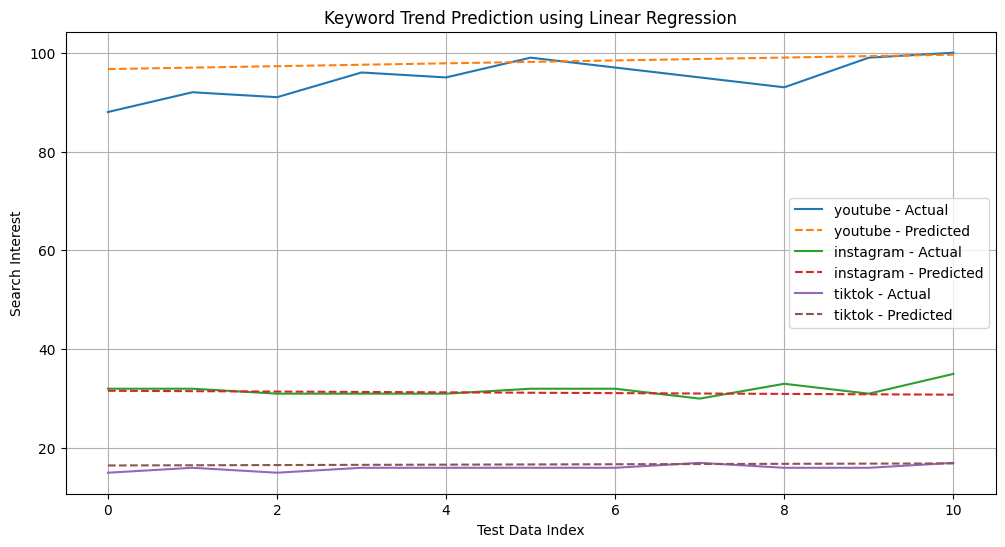

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for kw in keywords:
    plt.plot(results[kw]["y_test"].values, label=f"{kw} - Actual")
    plt.plot(results[kw]["y_pred"], '--', label=f"{kw} - Predicted")

plt.title("Keyword Trend Prediction using Linear Regression")
plt.xlabel("Test Data Index")
plt.ylabel("Search Interest")
plt.legend()
plt.grid(True)
plt.show()


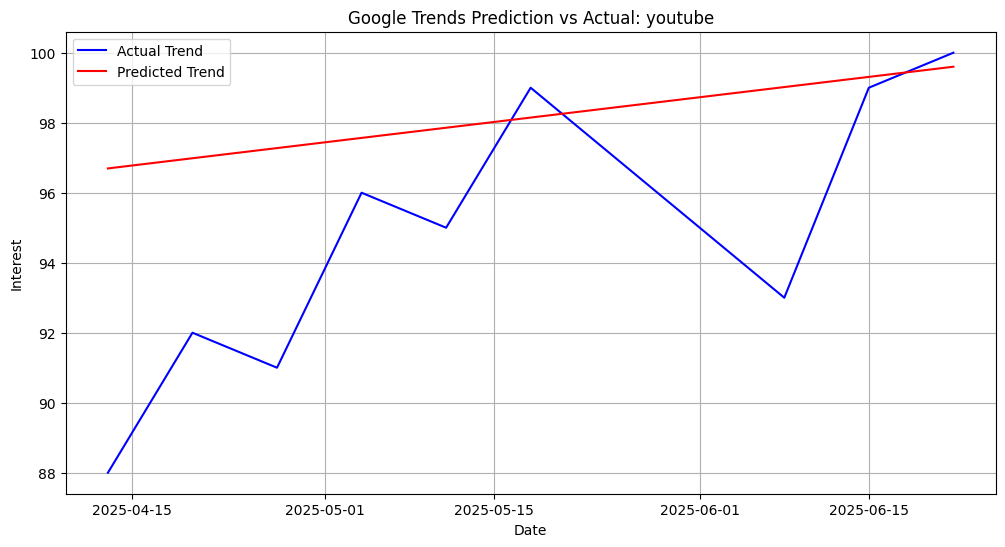

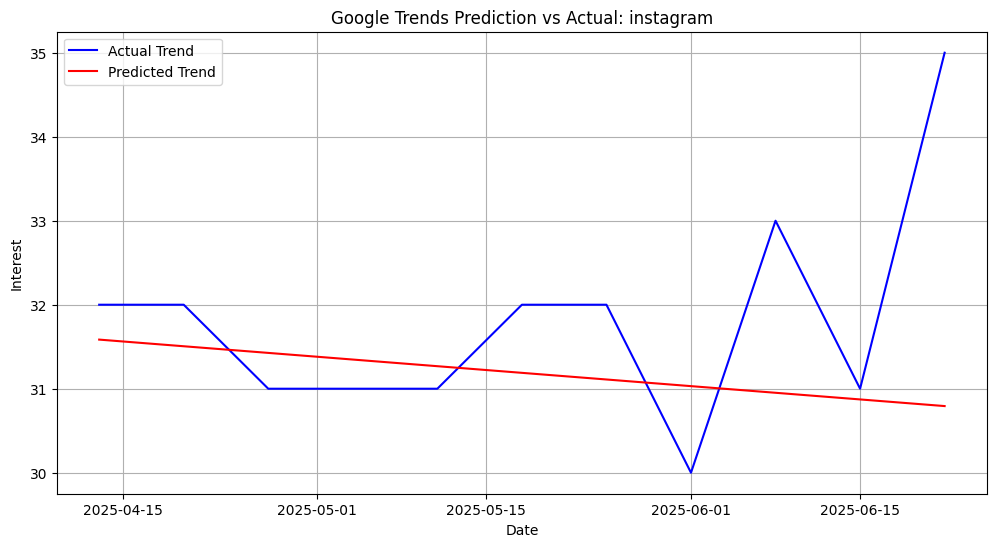

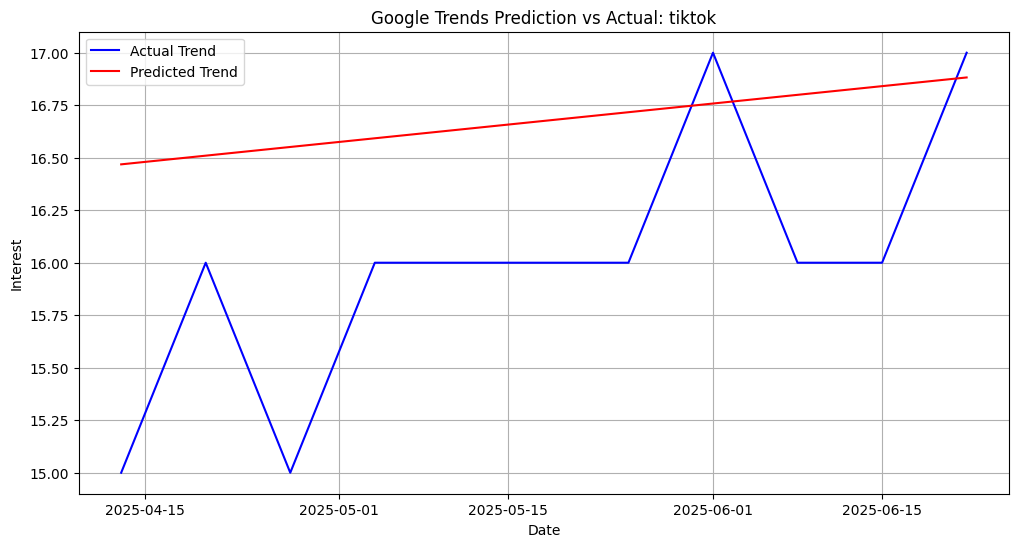

In [12]:
import matplotlib.pyplot as plt

for kw in keywords:
    y_test = results[kw]["y_test"]
    y_pred = results[kw]["y_pred"]

    plt.figure(figsize=(12, 6))
    plt.plot(y_test.index, y_test.values, label='Actual Trend', color='blue')
    plt.plot(y_test.index, y_pred, label='Predicted Trend', color='red')
    plt.title(f'Google Trends Prediction vs Actual: {kw}')
    plt.xlabel('Date')
    plt.ylabel('Interest')
    plt.legend()
    plt.grid(True)
    plt.show()


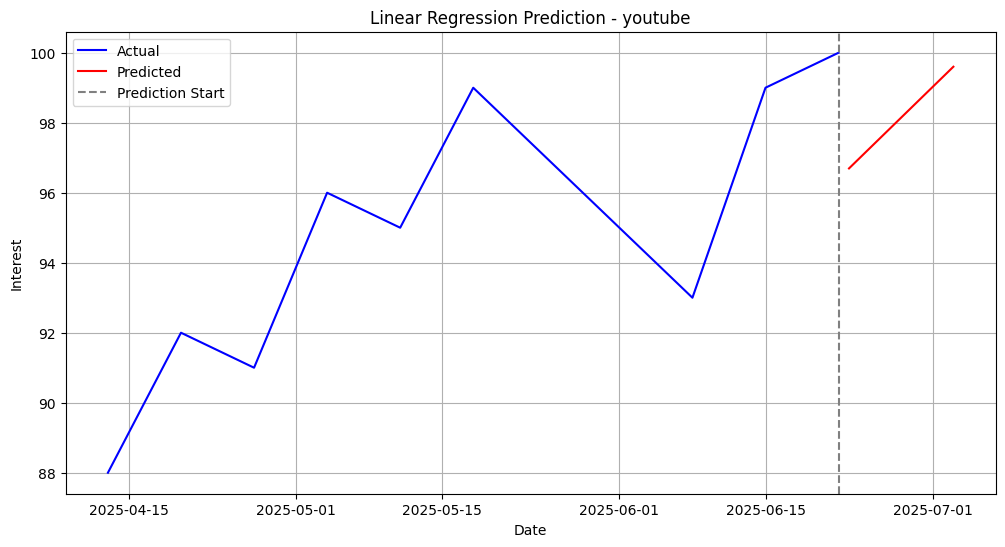

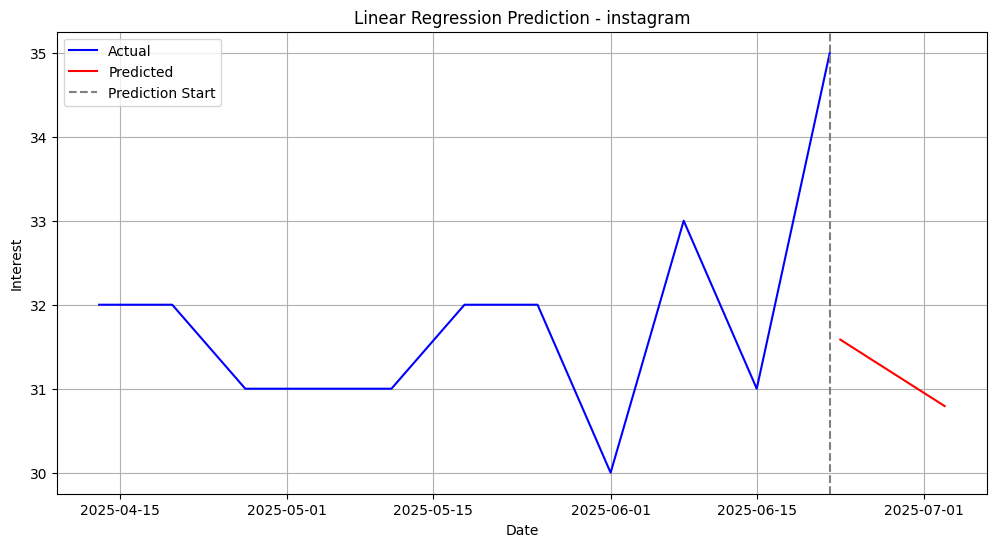

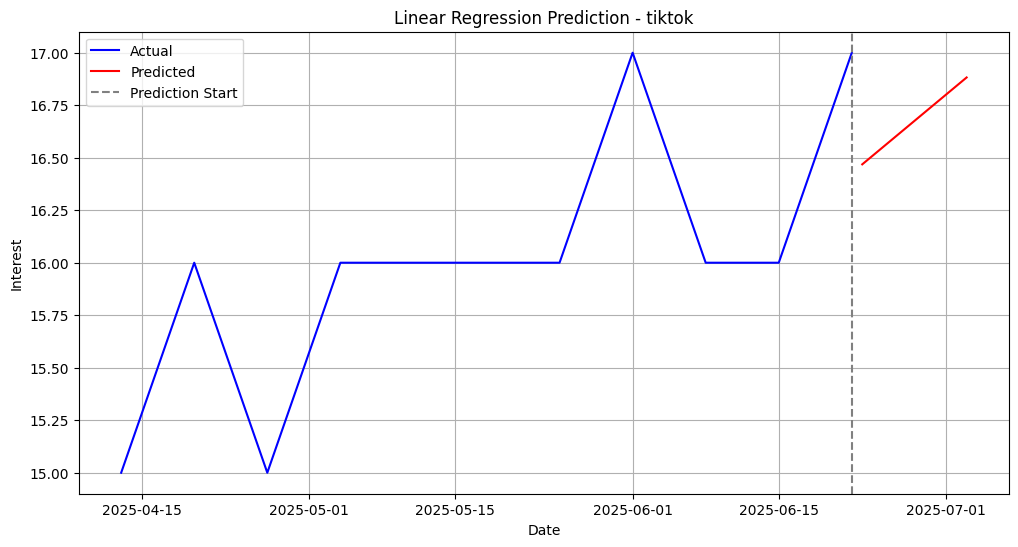

In [19]:
from datetime import timedelta
import matplotlib.pyplot as plt

for kw in keywords:
    # 실제 검색량과 예측값
    actual = results[kw]["y_test"]
    predicted = results[kw]["y_pred"]

    # 인덱스 기준 마지막 날짜
    last_date = actual.index[-1]

    # 예측 날짜 생성 (y_pred와 길이 맞춤)
    future_dates = [last_date + timedelta(days=i + 1) for i in range(len(predicted))]

    # 시각화
    plt.figure(figsize=(12, 6))
    plt.plot(actual.index, actual.values, label='Actual', color='blue')
    plt.plot(future_dates, predicted.values, label='Predicted', color='red')
    plt.axvline(last_date, color='gray', linestyle='--', label='Prediction Start')
    plt.xlabel("Date")
    plt.ylabel("Interest")
    plt.title(f"Linear Regression Prediction - {kw}")
    plt.legend()
    plt.grid(True)
    plt.show()


In [20]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.7 MB/s eta 0:00:00


In [25]:
!pip install streamlit pyngrok --quiet

In [31]:
# Step 1: Streamlit 백그라운드 실행
!streamlit run myapp.py &>/dev/null &

# Step 2: Ngrok 연결
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print("🔗 App URL:", public_url)



🔗 App URL: NgrokTunnel: "https://8f27-34-74-145-113.ngrok-free.app" -> "http://localhost:8501"


In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
from datetime import timedelta
from pytrends.request import TrendReq
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
import time

# ✅ 페이지 설정 + 좌우 마진
st.set_page_config(page_title="Google Trends 예측", layout="wide")
st.markdown("""
    <style>
    .block-container {
        max-width: 1000px;
        margin: auto;
        padding-left: 2rem;
        padding-right: 2rem;
    }
    </style>
""", unsafe_allow_html=True)

st.title("📈 Google Trends 키워드 예측 (LSTM 기반)")

# ✅ 키워드 입력
raw_input = st.text_input("🔍 예측할 키워드를 쉼표로 구분하여 입력하세요(영어로):", "youtube, instagram")

if raw_input:
    keywords = [kw.strip() for kw in raw_input.split(',') if kw.strip()]

    # ✅ pytrends로 데이터 수집
    pytrends = TrendReq(hl='en-US', tz=360)
    result_df = pd.DataFrame()

    for kw in keywords:
        st.markdown(f"### 🔄 '{kw}' 데이터 수집 중...")
        pytrends.build_payload([kw], cat=0, timeframe='today 5-y')
        df = pytrends.interest_over_time()
        time.sleep(15)

        if 'isPartial' in df.columns:
            df.drop(columns=['isPartial'], inplace=True)

        result_df[kw] = df[kw]

    st.subheader("📅 수집된 Google Trends 데이터")
    st.dataframe(result_df.tail())

    # ✅ 예측 결과 저장
    for kw in keywords:
        st.markdown(f"### 🔮 '{kw}' 예측 중...")

        # 정규화
        scaler = MinMaxScaler()
        scaled_data = scaler.fit_transform(result_df[kw].values.reshape(-1, 1))

        # 시퀀스 생성
        def create_dataset(data, time_step=14):
            X, y = [], []
            for i in range(len(data) - time_step - 1):
                X.append(data[i:(i + time_step), 0])
                y.append(data[i + time_step, 0])
            return np.array(X), np.array(y)

        time_step = 14
        X, y = create_dataset(scaled_data, time_step)

        if len(X) == 0:
            st.warning(f"⚠ '{kw}'는 데이터가 부족해서 예측할 수 없습니다.")
            continue

        X = X.reshape(X.shape[0], X.shape[1], 1)

        # LSTM 모델 정의
        model = Sequential()
        model.add(LSTM(32, input_shape=(time_step, 1)))
        model.add(Dense(1))
        model.compile(optimizer='adam', loss='mean_squared_error')
        model.fit(X, y, epochs=10, batch_size=8, verbose=0)

        # 미래 예측 (30일)
        future_input = X[-1]
        future_pred_scaled = []

        for _ in range(30):
            pred = model.predict(future_input.reshape(1, time_step, 1), verbose=0)
            future_pred_scaled.append(pred[0][0])
            future_input = np.append(future_input[1:], pred[0])

        future_pred = scaler.inverse_transform(np.array(future_pred_scaled).reshape(-1, 1)).flatten()
        last_date = result_df.index[-1]
        future_dates = [last_date + timedelta(days=i+1) for i in range(30)]

        # ✅ 시각화
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(result_df.index, result_df[kw], label="Actual", color="blue")
        ax.plot([last_date] + future_dates, [result_df[kw].iloc[-1]] + list(future_pred), label="Predicted", color="red", linewidth=2)
        ax.axvline(last_date, linestyle='--', color='gray', label="Prediction Start")

        ax.set_title(f"Google Trends Forecast - {kw}")
        ax.set_xlabel("Date")
        ax.set_ylabel("Search Interest")
        ax.legend()
        ax.grid(True)
        st.pyplot(fig)


In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import requests
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# 설정
API_KEY = 'YOUR_LASTFM_API_KEY'  # 🔐 여기에 본인의 Last.fm API Key 입력

# 페이지 스타일 설정
st.set_page_config(page_title="Music Trends Forecast", layout="wide")
st.markdown("""
    <style>
    .block-container {
        max-width: 1000px;
        margin: auto;
        padding-left: 2rem;
        padding-right: 2rem;
    }
    </style>
""", unsafe_allow_html=True)
st.title("🎵 Music Listening Trend Forecast (via Last.fm API + LSTM)")

# 사용자 입력
raw_input = st.text_input("🔍 예측할 음악 장르 또는 태그를 쉼표로 입력하세요 (예: kpop, jazz):", "kpop, jazz")

# 함수: 특정 태그로부터 트렌드 데이터 수집
def get_tag_weekly_data(tag):
    url = f"http://ws.audioscrobbler.com/2.0/?method=tag.gettoptracks&tag={tag}&api_key={API_KEY}&format=json&limit=100"
    res = requests.get(url)
    if res.status_code != 200:
        return None
    try:
        data = res.json()
        tracks = data['tracks']['track']
        # 각 트랙의 청취수 합산
        total_listeners = sum(int(t['listeners']) for t in tracks)
        return total_listeners
    except:
        return None

# 실행
if raw_input:
    tags = [tag.strip() for tag in raw_input.split(',') if tag.strip()]
    weekly_trend = {}
    for tag in tags:
        st.markdown(f"### 🔄 '{tag}'에 대한 데이터 수집 중...")

        trend_data = []
        dates = []

        # 최근 30주치 주간 추정 트렌드 수집
        for week in range(30, 0, -1):
            fake_date = datetime.now() - timedelta(weeks=week)
            listeners = get_tag_weekly_data(tag)
            if listeners:
                trend_data.append(listeners)
                dates.append(fake_date.strftime("%Y-%m-%d"))
            else:
                trend_data.append(0)
                dates.append(fake_date.strftime("%Y-%m-%d"))

        df = pd.DataFrame({'date': pd.to_datetime(dates), tag: trend_data})
        df.set_index('date', inplace=True)

        # 예측
        st.markdown(f"### 🔮 '{tag}'에 대한 트렌드 예측 중...")
        scaler = MinMaxScaler()
        scaled_data = scaler.fit_transform(df[tag].values.reshape(-1, 1))

        def create_dataset(data, time_step=4):
            X, y = [], []
            for i in range(len(data) - time_step - 1):
                X.append(data[i:(i + time_step), 0])
                y.append(data[i + time_step, 0])
            return np.array(X), np.array(y)

        time_step = 4
        X, y = create_dataset(scaled_data, time_step)

        if len(X) == 0:
            st.warning(f"⚠ '{tag}'에 대한 예측에 사용할 수 있는 충분한 데이터가 없습니다.")
            continue

        X = X.reshape(X.shape[0], X.shape[1], 1)
        model = Sequential()
        model.add(LSTM(32, input_shape=(time_step, 1)))
        model.add(Dense(1))
        model.compile(optimizer='adam', loss='mean_squared_error')
        model.fit(X, y, epochs=10, batch_size=8, verbose=0)

        # 미래 4주 예측
        future_input = X[-1]
        future_pred_scaled = []

        for _ in range(4):
            pred = model.predict(future_input.reshape(1, time_step, 1), verbose=0)
            future_pred_scaled.append(pred[0][0])
            future_input = np.append(future_input[1:], pred[0])

        future_pred = scaler.inverse_transform(np.array(future_pred_scaled).reshape(-1, 1)).flatten()
        last_date = df.index[-1]
        future_dates = [last_date + timedelta(weeks=i+1) for i in range(4)]

        # 시각화
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(df.index, df[tag], label="Actual", color="blue")
        ax.plot([last_date] + future_dates, [df[tag].iloc[-1]] + list(future_pred),
                label="Predicted", color="red", linewidth=2)
        ax.axvline(last_date, linestyle='--', color='gray', label="Prediction Start")
        ax.set_title(f"Music Trend Forecast - {tag}")
        ax.set_xlabel("Date")
        ax.set_ylabel("Listeners (aggregated)")
        ax.legend()
        ax.grid(True)
        st.pyplot(fig)